## **Analisis exploratorio**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [2]:
USUARIO = "postgres"
PASSWORD = "1028"
HOST = "localhost"
PUERTO = "5432"
BASE_DATOS = "dw_analisis_criminalidad"

engine = create_engine(
    f"postgresql+psycopg2://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}"
)

print("Conexión creada correctamente.")

Conexión creada correctamente.


#### **1. Distribución territorial**

##### **1.1. Distribucion departamental**

In [ ]:
query = """
SELECT
    u.departamento,
    d.tipo_delito,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_ubicacion AS u
    ON f.id_ubicacion = u.id_ubicacion
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
GROUP BY u.departamento, d.tipo_delito
ORDER BY u.departamento, cantidad_delitos DESC;
"""

df_departamento_delito = pd.read_sql(query, engine)
df_departamento_delito.head()

,departamento,tipo_delito,cantidad_delitos
0,Antioquia,Lesiones personales,180781
1,Antioquia,Violencia intrafamiliar,157423
2,Antioquia,Hurto de motocicletas y automotores,100928
3,Antioquia,Hurto a residencias y entidades comerciales,71160
4,Antioquia,Delitos sexuales,41389


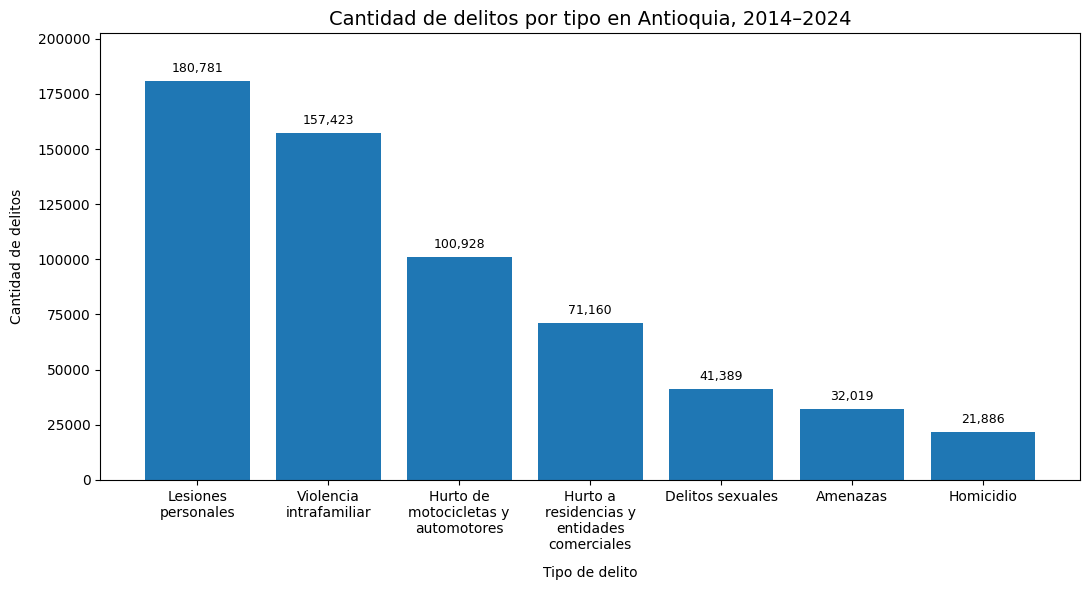

In [36]:
import matplotlib.pyplot as plt
import textwrap

# Copia de los datos
df_grafica = df_departamento_delito.copy()

# Ordenar de mayor a menor
df_grafica = df_grafica.sort_values(
    "cantidad_delitos",
    ascending=False
)

# Crear etiquetas con saltos de línea
etiquetas = [
    "\n".join(textwrap.wrap(str(delito), width=18))
    for delito in df_grafica["tipo_delito"]
]

# Crear gráfico
plt.figure(figsize=(11, 6))

plt.bar(
    range(len(df_grafica)),
    df_grafica["cantidad_delitos"]
)

plt.title(
    "Cantidad de delitos por tipo en Antioquia, 2014–2024",
    fontsize=14
)

plt.xlabel("Tipo de delito", labelpad=10)
plt.ylabel("Cantidad de delitos", labelpad=10)

# Etiquetas horizontales con saltos de línea
plt.xticks(
    range(len(df_grafica)),
    etiquetas,
    rotation=0,
    ha="center"
)

# Dar margen superior al eje Y
max_valor = df_grafica["cantidad_delitos"].max()
plt.ylim(0, max_valor * 1.12)

# Valores sobre las barras
for i, valor in enumerate(df_grafica["cantidad_delitos"]):
    plt.text(
        i,
        valor + max_valor * 0.015,
        f"{valor:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

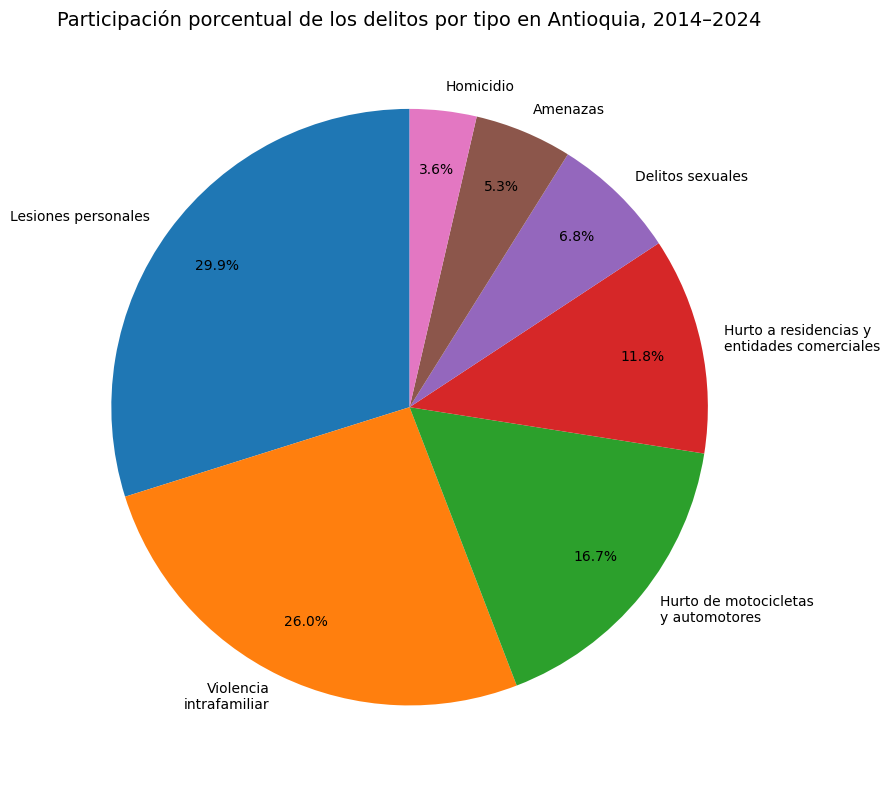

In [37]:
import matplotlib.pyplot as plt
import textwrap

# Copia de los datos
df_grafica = df_departamento_delito.copy()

# Calcular porcentaje
df_grafica["porcentaje"] = (
    df_grafica["cantidad_delitos"] /
    df_grafica["cantidad_delitos"].sum()
) * 100

# Ordenar de mayor a menor
df_grafica = df_grafica.sort_values(
    "cantidad_delitos",
    ascending=False
)

# Crear etiquetas con saltos de línea
etiquetas = [
    "\n".join(textwrap.wrap(str(delito), width=22))
    for delito in df_grafica["tipo_delito"]
]

# Crear gráfico
plt.figure(figsize=(10, 8))

plt.pie(
    df_grafica["cantidad_delitos"],
    labels=etiquetas,
    autopct="%1.1f%%",
    startangle=90,
    labeldistance=1.08,
    pctdistance=0.80
)

plt.title(
    "Participación porcentual de los delitos por tipo en Antioquia, 2014–2024",
    fontsize=14
)

plt.tight_layout()
plt.show()

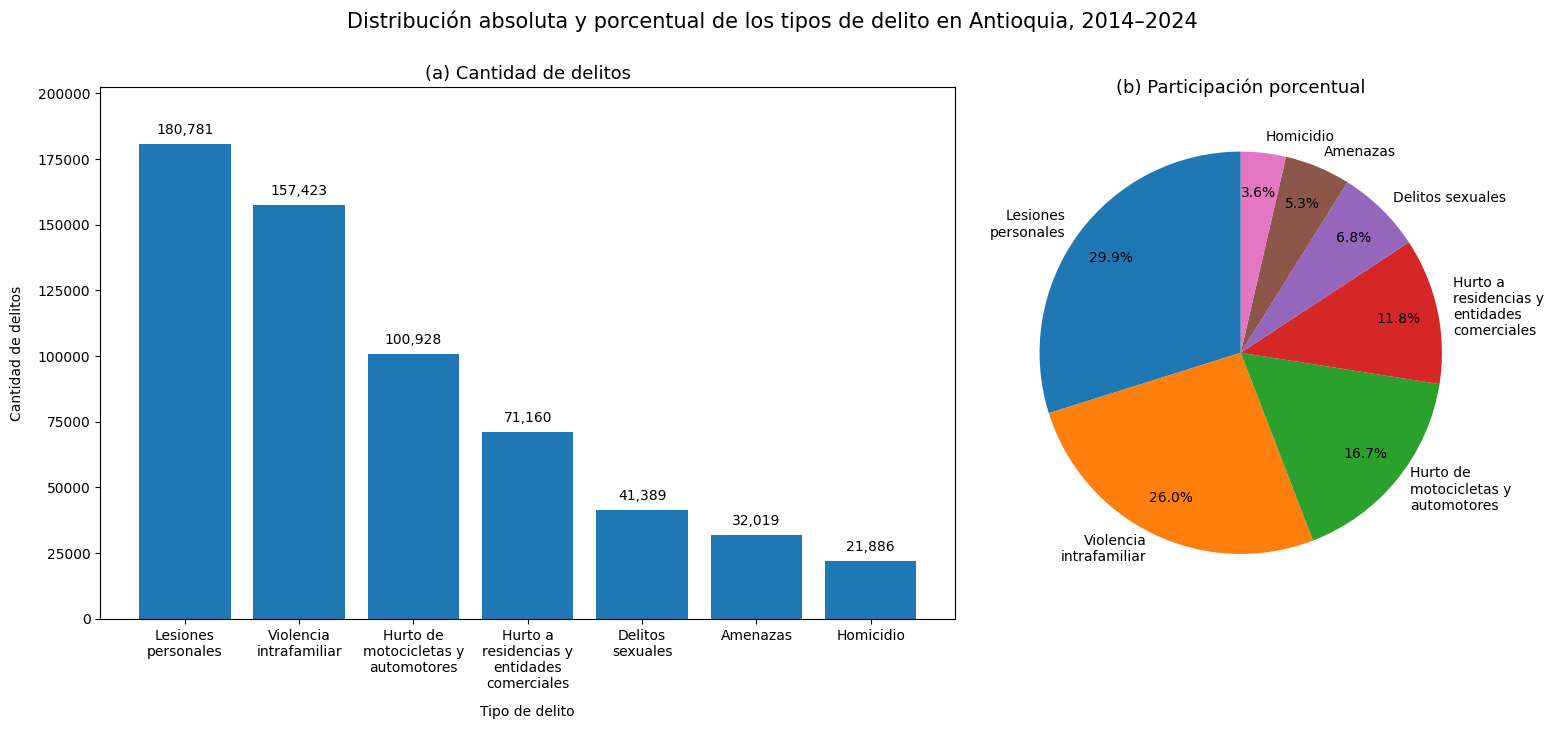

In [59]:
import matplotlib.pyplot as plt
import textwrap

# Copia de los datos
df_grafica = df_departamento_delito.copy()

# Ordenar de mayor a menor
df_grafica = df_grafica.sort_values(
    "cantidad_delitos",
    ascending=False
)

# Calcular porcentaje
df_grafica["porcentaje"] = (
    df_grafica["cantidad_delitos"] /
    df_grafica["cantidad_delitos"].sum()
) * 100

# Etiquetas para las gráficas
etiquetas_barras = [
    "\n".join(textwrap.wrap(str(delito), width=15))
    for delito in df_grafica["tipo_delito"]
]

etiquetas_torta = [
    "\n".join(textwrap.wrap(str(delito), width=18))
    for delito in df_grafica["tipo_delito"]
]

# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [1.70, 1]}
)

# Controlar manualmente el espacio entre las gráficas
plt.subplots_adjust(
    wspace=0.05,
    top=0.86,
    bottom=0.10,
    left=0.08,
    right=0.95
)

# ==========================================================
# (a) DISTRIBUCIÓN ABSOLUTA
# ==========================================================

ax1.bar(
    range(len(df_grafica)),
    df_grafica["cantidad_delitos"]
)

ax1.set_title(
    "(a) Cantidad de delitos",
    fontsize=13
)

ax1.set_xlabel(
    "Tipo de delito",
    labelpad=10
)

ax1.set_ylabel(
    "Cantidad de delitos",
    labelpad=10
)

ax1.set_xticks(range(len(df_grafica)))

ax1.set_xticklabels(
    etiquetas_barras,
    rotation=0,
    ha="center"
)

max_valor = df_grafica["cantidad_delitos"].max()

ax1.set_ylim(
    0,
    max_valor * 1.12
)

for i, valor in enumerate(df_grafica["cantidad_delitos"]):
    ax1.text(
        i,
        valor + max_valor * 0.015,
        f"{valor:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# ==========================================================
# (b) DISTRIBUCIÓN PORCENTUAL
# ==========================================================

ax2.pie(
    df_grafica["cantidad_delitos"],
    labels=etiquetas_torta,
    autopct="%1.1f%%",
    startangle=90,
    labeldistance=1.08,
    pctdistance=0.80
)

ax2.set_title(
    "(b) Participación porcentual",
    fontsize=13
)

# ==========================================================
# TÍTULO GENERAL
# ==========================================================

fig.suptitle(
    "Distribución absoluta y porcentual de los tipos de delito "
    "en Antioquia, 2014–2024",
    fontsize=15,
    y=0.97
)

plt.show()

In [22]:
print("Total de delitos:", df_departamento_delito["cantidad_delitos"].sum())
print("Departamentos:", df_departamento_delito["departamento"].nunique())
print("Tipos de delito:", df_departamento_delito["tipo_delito"].nunique())

Total de delitos: 605586
Departamentos: 1
Tipos de delito: 7


##### **1.2. Distribucion municipal**

In [10]:
# Consulta para obtener los 10 municipios con mayor cantidad de registros
query_top10 = """
    SELECT
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS cantidad_delitos
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.municipio,
        u.departamento
    ORDER BY
        cantidad_delitos DESC
    LIMIT 10;
"""

df_top10 = pd.read_sql(query_top10, engine)
df_top10

,municipio,departamento,cantidad_delitos
0,Medellín (Ct),Antioquia,314391
1,Bello,Antioquia,42504
2,Itagui,Antioquia,26248
3,Envigado,Antioquia,16655
4,Rionegro,Antioquia,10791
5,Apartadó,Antioquia,10440
6,Copacabana,Antioquia,9146
7,Caucasia,Antioquia,7738
8,Sabaneta,Antioquia,7647
9,Turbo,Antioquia,7440


In [11]:
query_municipios_delito = """
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
)

SELECT
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_ubicacion AS u
    ON f.id_ubicacion = u.id_ubicacion
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN top_municipios AS tm
    ON f.id_ubicacion = tm.id_ubicacion
GROUP BY
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    tm.total_municipio
ORDER BY
    tm.total_municipio DESC,
    cantidad_delitos DESC;
"""

df_municipios_delito = pd.read_sql(query_municipios_delito, engine)

df_municipios_delito

,municipio,departamento,tipo_delito,cantidad_delitos
0,Medellín (Ct),Antioquia,Violencia intrafamiliar,89249
1,Medellín (Ct),Antioquia,Lesiones personales,84027
2,Medellín (Ct),Antioquia,Hurto de motocicletas y automotores,67005
3,Medellín (Ct),Antioquia,Hurto a residencias y entidades comerciales,38367
4,Medellín (Ct),Antioquia,Delitos sexuales,19219
...,...,...,...,...
65,Turbo,Antioquia,Homicidio,734
66,Turbo,Antioquia,Amenazas,683
67,Turbo,Antioquia,Hurto de motocicletas y automotores,677
68,Turbo,Antioquia,Delitos sexuales,560


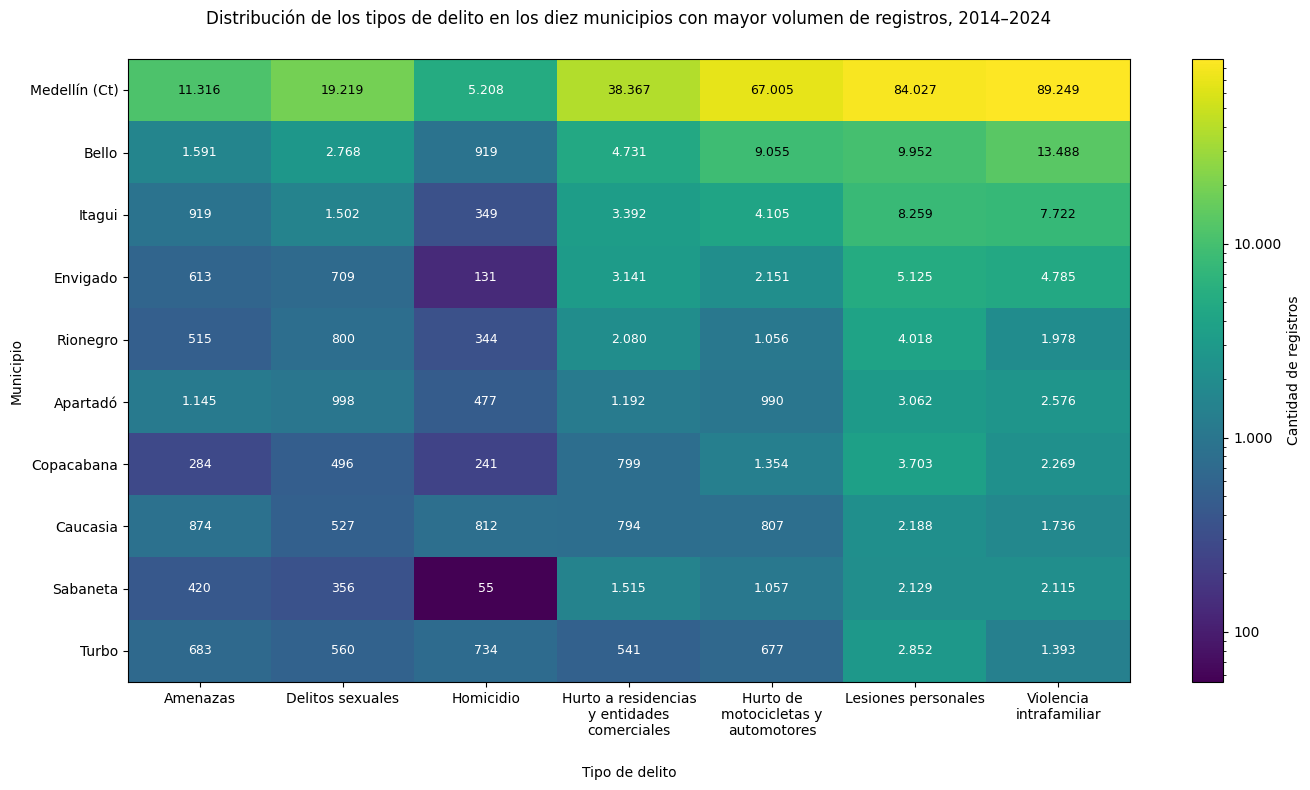

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from textwrap import fill

# ==========================================================
# PREPARACIÓN DE LOS DATOS
# ==========================================================

# Crear tabla municipio x tipo de delito
tabla_heatmap = df_municipios_delito.pivot_table(
    index=["municipio", "departamento"],
    columns="tipo_delito",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

# Calcular total para ordenar los municipios
tabla_heatmap["Total"] = tabla_heatmap.sum(axis=1)

# Ordenar de mayor a menor volumen
tabla_heatmap = tabla_heatmap.sort_values("Total", ascending=False)

# Eliminar columna auxiliar
tabla_heatmap = tabla_heatmap.drop(columns="Total")

# Limpiar nombres
municipios = [
    f"{municipio}"
    for municipio, departamento in tabla_heatmap.index
]

# Convertir a matriz
datos = tabla_heatmap.to_numpy()

# ==========================================================
# ESCALA LOGARÍTMICA PARA LA INTENSIDAD DEL COLOR
# ==========================================================

# Obtener el menor valor positivo para evitar problemas con log(0)
valores_positivos = datos[datos > 0]

norm = LogNorm(
    vmin=valores_positivos.min(),
    vmax=valores_positivos.max()
)

# ==========================================================
# CREACIÓN DEL HEATMAP
# ==========================================================

# Etiquetas originales
delitos = tabla_heatmap.columns.tolist()

# Partir automáticamente las etiquetas largas en varias líneas
delitos_cortos = [
    fill(delito, width=20)
    for delito in delitos
]

fig, ax = plt.subplots(figsize=(14, 8))

imagen = ax.imshow(
    datos,
    aspect="auto",
    norm=norm
)

# Eje X: tipos de delito
ax.set_xticks(np.arange(len(delitos)))
ax.set_xticklabels(
    delitos_cortos,
    rotation=0,
    ha="center"
)

# Eje Y: municipios
ax.set_yticks(np.arange(len(municipios)))
ax.set_yticklabels(municipios)

# Etiquetas
ax.set_xlabel("Tipo de delito", labelpad=20)
ax.set_ylabel("Municipio")

ax.set_title(
    "Distribución de los tipos de delito en los diez municipios con mayor volumen de registros, 2014–2024",
    pad=25
)

# ==========================================================
# VALORES EN LAS CELDAS
# ==========================================================

for i in range(datos.shape[0]):
    for j in range(datos.shape[1]):
        valor = datos[i, j]

        texto = f"{int(valor):,}".replace(",", ".")

        # Determinar contraste del texto según intensidad
        if valor > 0:
            # Obtener el color de fondo de la celda
            rgba = imagen.cmap(norm(valor))

            # Calcular luminancia del color
            r, g, b, _ = rgba

            luminancia = (
                0.299 * r +
                0.587 * g +
                0.114 * b
            )

            # Fondo oscuro -> texto blanco
            # Fondo claro -> texto negro
            color_texto = "white" if luminancia < 0.5 else "black"

            ax.text(
                j,
                i,
                texto,
                ha="center",
                va="center",
                fontsize=9,
                color=color_texto
            )

# ==========================================================
# BARRA DE COLOR
# ==========================================================

cbar = fig.colorbar(imagen, ax=ax)

cbar.set_label("Cantidad de registros")

cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", "."))
)

plt.tight_layout()
plt.show()

#### **2. Caracterizacion de las victimas**

##### **2.1. Caracterizacion general de las victimas**

In [4]:
query_genero = """
SELECT
    d.tipo_delito,
    v.genero,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
GROUP BY
    d.tipo_delito,
    v.genero
ORDER BY
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_genero = pd.read_sql(query_genero, engine)

print("Resultados: tipo de delito × género")
display(df_genero)

Resultados: tipo de delito × género


,tipo_delito,genero,cantidad_delitos
0,Amenazas,Masculino,18977
1,Amenazas,Femenino,12763
2,Amenazas,No reportado,279
3,Delitos sexuales,Femenino,34845
4,Delitos sexuales,Masculino,6297
5,Delitos sexuales,No reportado,247
6,Homicidio,Masculino,20200
7,Homicidio,Femenino,1686
8,Hurto a residencias y entidades comerciales,No reportado,67249
9,Hurto a residencias y entidades comerciales,Masculino,2178


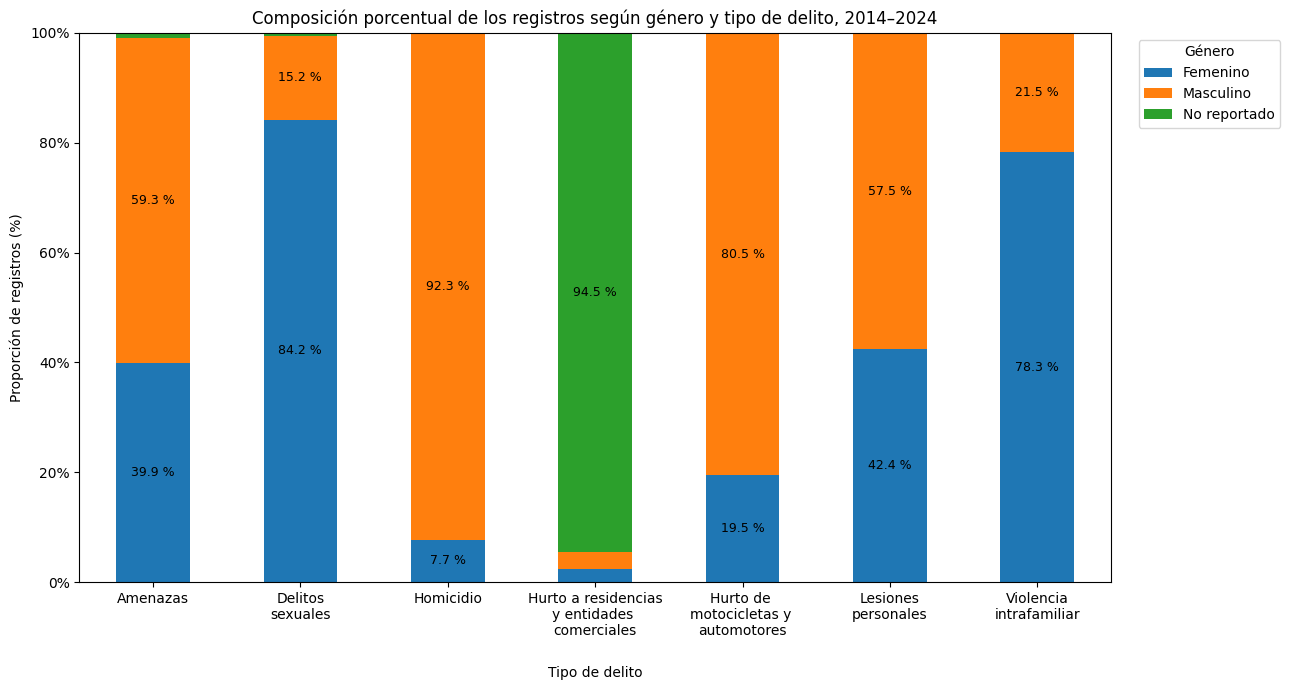

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ==========================================================
# PREPARACIÓN DE DATOS: TIPO DE DELITO × GÉNERO
# ==========================================================

# Convertir a tabla tipo_delito x genero
tabla_genero = df_genero.pivot_table(
    index="tipo_delito",
    columns="genero",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

# Calcular porcentaje dentro de cada tipo de delito
tabla_genero_pct = tabla_genero.div(
    tabla_genero.sum(axis=1),
    axis=0
) * 100

# Ordenar los delitos según el orden deseado
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

tabla_genero_pct = tabla_genero_pct.reindex(orden_delitos)

# ==========================================================
# GRÁFICA
# ==========================================================

ax = tabla_genero_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

ax.set_xlabel("Tipo de delito", labelpad=20)
ax.set_ylabel("Proporción de registros (%)")
ax.set_title(
    "Composición porcentual de los registros según género y tipo de delito, 2014–2024"
)

# Eje Y de 0 a 100
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())

# Rotación de etiquetas
ax.set_xticklabels(
    [
        "Amenazas",
        "Delitos\nsexuales",
        "Homicidio",
        "Hurto a residencias\ny entidades \ncomerciales",
        "Hurto de \nmotocicletas y \nautomotores",
        "Lesiones\npersonales",
        "Violencia\nintrafamiliar"
    ],
    rotation=0,
    ha="center"
)

for i in range(tabla_genero_pct.shape[0]):
    acumulado = 0
    
    for j in range(tabla_genero_pct.shape[1]):
        valor = tabla_genero_pct.iloc[i, j]
        
        if valor >= 5:
            ax.text(
                i,
                acumulado + valor / 2,
                f"{valor:.1f} %",
                ha="center",
                va="center",
                fontsize=9
            )
        
        acumulado += valor
        
ax.legend(
    title="Género",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [6]:
query_edad = """
SELECT
    d.tipo_delito,
    v.grupo_etario,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
GROUP BY
    d.tipo_delito,
    v.grupo_etario
ORDER BY
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_grupo = pd.read_sql(query_edad, engine)

print("Resultados: tipo de delito × grupo etario")
display(df_grupo)

Resultados: tipo de delito × grupo etario


,tipo_delito,grupo_etario,cantidad_delitos
0,Amenazas,Adultos,30955
1,Amenazas,Adolescentes,833
2,Amenazas,Menores,222
3,Amenazas,No reportado,9
4,Delitos sexuales,Adultos,25652
5,Delitos sexuales,Menores,8814
6,Delitos sexuales,Adolescentes,6890
7,Delitos sexuales,No reportado,33
8,Homicidio,Adultos,20732
9,Homicidio,Adolescentes,1066


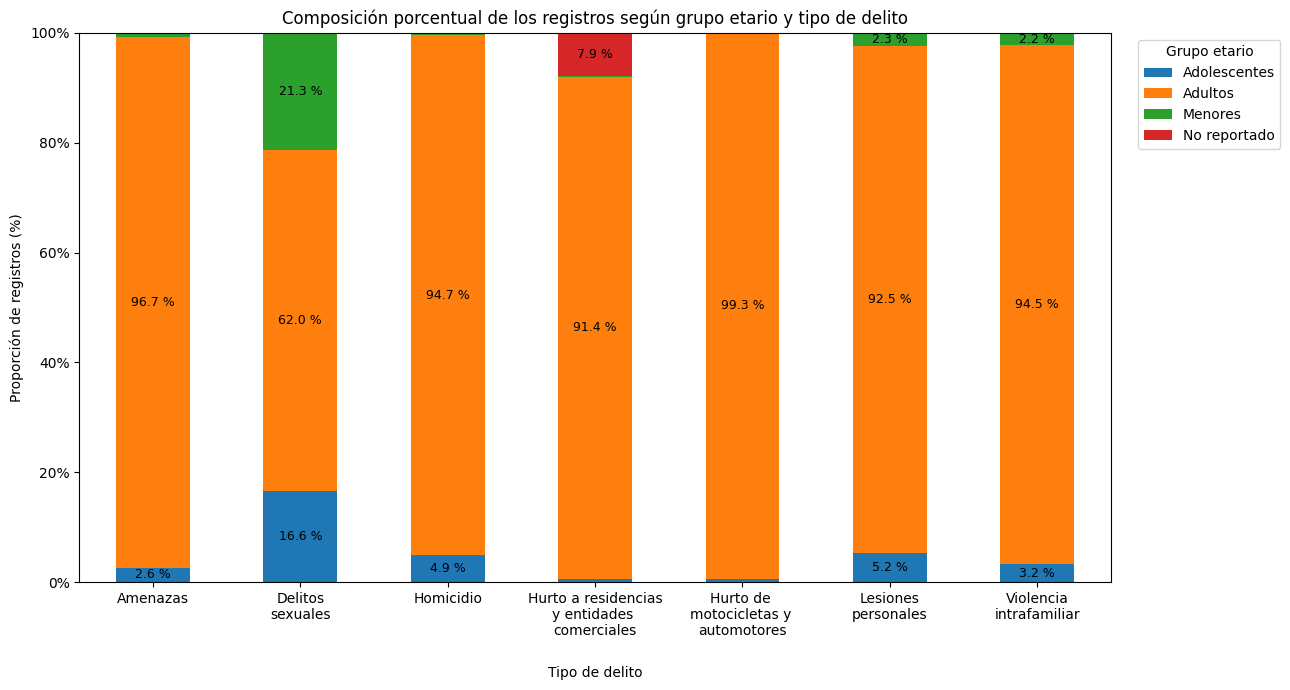

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ==========================================================
# PREPARACIÓN DE DATOS: TIPO DE DELITO × GRUPO ETARIO
# ==========================================================

tabla_edad = df_grupo.pivot_table(
    index="tipo_delito",
    columns="grupo_etario",
    values="cantidad_delitos",
    aggfunc="sum",
    fill_value=0
)

# Calcular proporción dentro de cada tipo de delito
tabla_edad_pct = tabla_edad.div(
    tabla_edad.sum(axis=1),
    axis=0
) * 100

# Orden de los delitos
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

tabla_edad_pct = tabla_edad_pct.reindex(orden_delitos)

# ==========================================================
# GRÁFICA
# ==========================================================

ax = tabla_edad_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

ax.set_xlabel("Tipo de delito", labelpad=20)
ax.set_ylabel("Proporción de registros (%)")

ax.set_title(
    "Composición porcentual de los registros según grupo etario y tipo de delito"
)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())

# Etiquetas en dos líneas
ax.set_xticklabels(
    [
        "Amenazas",
        "Delitos\nsexuales",
        "Homicidio",
        "Hurto a residencias\ny entidades \ncomerciales",
        "Hurto de \nmotocicletas y \nautomotores",
        "Lesiones\npersonales",
        "Violencia\nintrafamiliar"
    ],
    rotation=0,
    ha="center"
)

# ==========================================================
# ETIQUETAS DE PORCENTAJE
# Solo mostrar segmentos >= 5 %
# ==========================================================

for i in range(tabla_edad_pct.shape[0]):
    acumulado = 0

    for j in range(tabla_edad_pct.shape[1]):
        valor = tabla_edad_pct.iloc[i, j]

        if valor >= 2:
            ax.text(
                i,
                acumulado + valor / 2,
                f"{valor:.1f} %",
                ha="center",
                va="center",
                fontsize=9
            )

        acumulado += valor

# ==========================================================
# LEYENDA
# ==========================================================

ax.legend(
    title="Grupo etario",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

##### **2.2. Caracterizacion de victimas en los municipios con mayor volumen de registros**

In [3]:
query_municipio_genero = """
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
)

SELECT
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    v.genero,
    SUM(f.cantidad_delitos) AS cantidad_delitos
FROM fact_delitos AS f
INNER JOIN dim_delito AS d
    ON f.id_delito = d.id_delito
INNER JOIN dim_victima AS v
    ON f.id_victima = v.id_victima
INNER JOIN top_municipios AS tm
    ON f.id_ubicacion = tm.id_ubicacion
GROUP BY
    tm.municipio,
    tm.departamento,
    d.tipo_delito,
    v.genero,
    tm.total_municipio
ORDER BY
    tm.total_municipio DESC,
    tm.municipio,
    d.tipo_delito,
    cantidad_delitos DESC;
"""

df_municipio_genero = pd.read_sql(
    query_municipio_genero,
    engine
)

print("Resultados del análisis municipio × tipo de delito × género:")
display(df_municipio_genero)

Resultados del análisis municipio × tipo de delito × género:


,municipio,departamento,tipo_delito,genero,cantidad_delitos
0,Medellín (Ct),Antioquia,Amenazas,Masculino,6245
1,Medellín (Ct),Antioquia,Amenazas,Femenino,4888
2,Medellín (Ct),Antioquia,Amenazas,No reportado,183
3,Medellín (Ct),Antioquia,Delitos sexuales,Femenino,16017
4,Medellín (Ct),Antioquia,Delitos sexuales,Masculino,3061
...,...,...,...,...,...
187,Turbo,Antioquia,Lesiones personales,Femenino,1297
188,Turbo,Antioquia,Lesiones personales,No reportado,1
189,Turbo,Antioquia,Violencia intrafamiliar,Femenino,1241
190,Turbo,Antioquia,Violencia intrafamiliar,Masculino,150


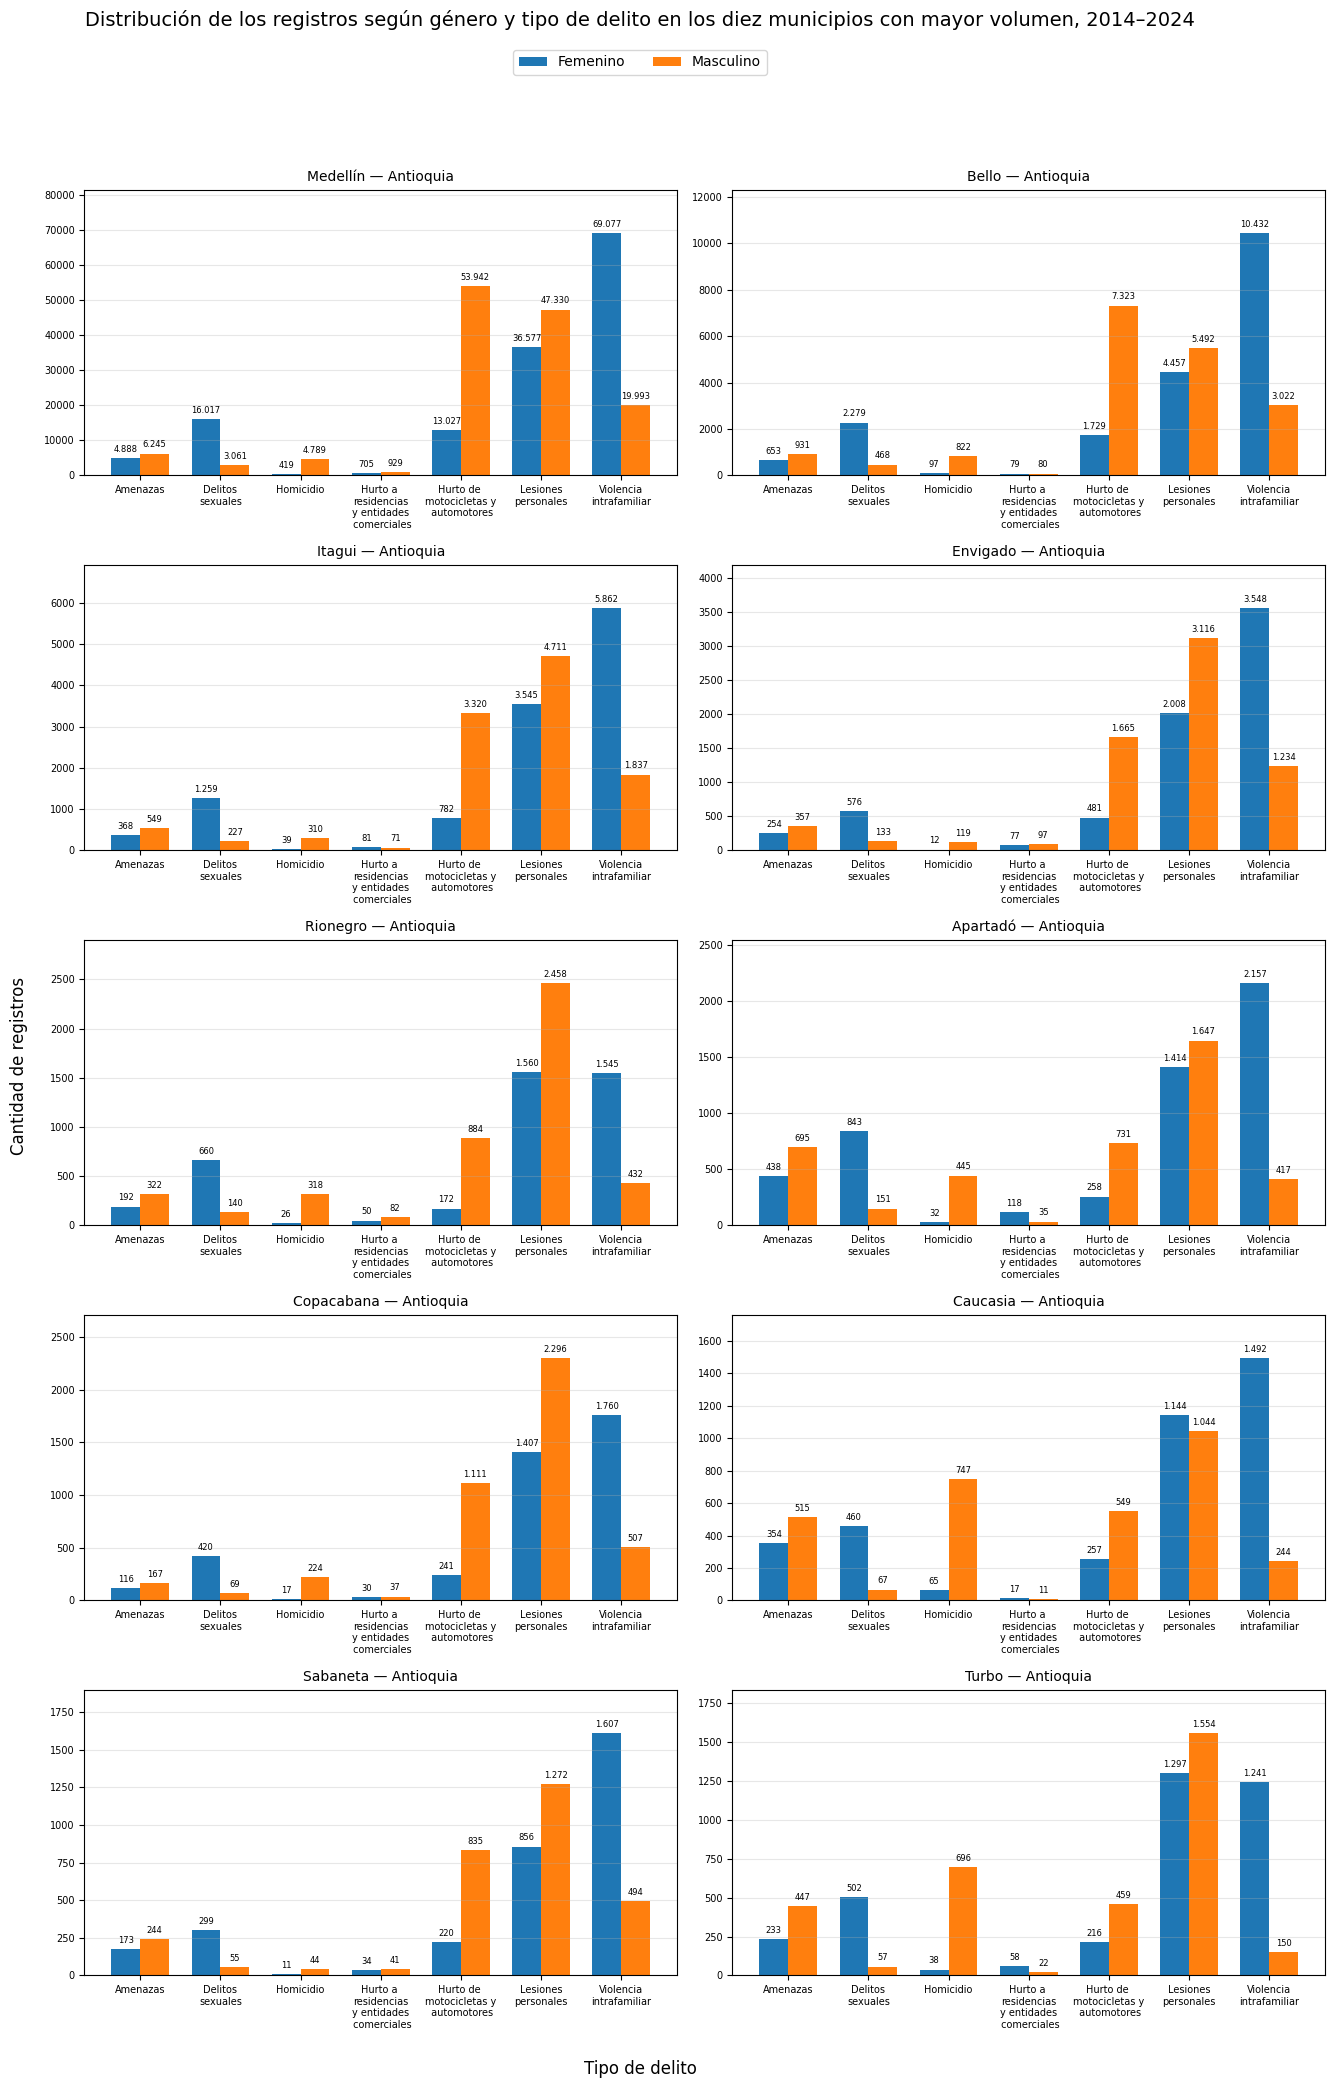

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PREPARACIÓN DE DATOS
# ==========================================================

df_plot = df_municipio_genero.copy()

# Normalizar género
df_plot["genero_limpio"] = (
    df_plot["genero"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Mantener únicamente femenino y masculino
df_plot = df_plot[
    df_plot["genero_limpio"].isin(["FEMENINO", "MASCULINO"])
]

# Orden de los tipos de delito
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

# Etiquetas más cortas para la gráfica
etiquetas_delitos = [
    "Amenazas",
    "Delitos\nsexuales",
    "Homicidio",
    "Hurto a \nresidencias\ny entidades\n comerciales",
    "Hurto de \nmotocicletas y\n automotores",
    "Lesiones\npersonales",
    "Violencia\nintrafamiliar"
]

# Ordenar municipios según cantidad total de registros
orden_municipios = (
    df_municipio_genero
    .groupby(["municipio", "departamento"])["cantidad_delitos"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# ==========================================================
# FIGURA: 2 COLUMNAS × 5 FILAS
# ==========================================================

fig, axes = plt.subplots(
    5, 2,
    figsize=(14, 22)
)

axes = axes.flatten()

for ax, (municipio, departamento) in zip(axes, orden_municipios):

    # ------------------------------------------------------
    # Filtrar municipio
    # ------------------------------------------------------

    df_municipio = df_plot[
        (df_plot["municipio"] == municipio) &
        (df_plot["departamento"] == departamento)
    ]

    # ------------------------------------------------------
    # Tabla tipo de delito × género
    # ------------------------------------------------------

    tabla = df_municipio.pivot_table(
        index="tipo_delito",
        columns="genero_limpio",
        values="cantidad_delitos",
        aggfunc="sum",
        fill_value=0
    )

    tabla = tabla.reindex(
        orden_delitos,
        fill_value=0
    )

    femenino = tabla.get(
        "FEMENINO",
        pd.Series(0, index=tabla.index)
    ).to_numpy()

    masculino = tabla.get(
        "MASCULINO",
        pd.Series(0, index=tabla.index)
    ).to_numpy()

    # ------------------------------------------------------
    # Barras agrupadas
    # ------------------------------------------------------

    x = np.arange(len(orden_delitos))
    width = 0.36

    barras_femenino = ax.bar(
        x - width / 2,
        femenino,
        width,
        label="Femenino"
    )

    barras_masculino = ax.bar(
        x + width / 2,
        masculino,
        width,
        label="Masculino"
    )

    # ------------------------------------------------------
    # Etiquetas de cantidad sobre las barras
    # ------------------------------------------------------

    for barra in barras_femenino:
        altura = barra.get_height()

        if altura > 0:
            ax.annotate(
                f"{int(altura):,}".replace(",", "."),
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=6
            )

    for barra in barras_masculino:
        altura = barra.get_height()

        if altura > 0:
            ax.annotate(
                f"{int(altura):,}".replace(",", "."),
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=6
            )

    # ------------------------------------------------------
    # Eje X
    # ------------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(
        etiquetas_delitos,
        rotation=0,
        fontsize=7
    )

    # ------------------------------------------------------
    # Eje Y independiente
    # ------------------------------------------------------

    max_valor = max(
        femenino.max(),
        masculino.max()
    )

    ax.set_ylim(0, max_valor * 1.18)

    ax.ticklabel_format(
        axis="y",
        style="plain"
    )
    # ← Aquí haces las etiquetas más pequeñas
    ax.tick_params(axis='y', labelsize=7)

    # ------------------------------------------------------
    # Título del municipio
    # ------------------------------------------------------

    municipio_limpio = municipio.replace(" (Ct)", "")
    departamento_limpio = departamento.replace(" (Ct)", "")

    ax.set_title(
        f"{municipio_limpio} — {departamento_limpio}",
        fontsize=10
    )

    # ------------------------------------------------------
    # Cuadrícula
    # ------------------------------------------------------

    ax.grid(
        axis="y",
        alpha=0.3
    )

# ==========================================================
# EJES GENERALES
# ==========================================================

fig.supxlabel(
    "Tipo de delito",
    y=0.04
)

fig.supylabel(
    "Cantidad de registros",
    x=0.05
)

fig.suptitle(
    "Distribución de los registros según género y tipo de delito "
    "en los diez municipios con mayor volumen, 2014–2024",
    fontsize=14
)

# ==========================================================
# LEYENDA ÚNICA
# ==========================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2
)

plt.tight_layout(
    rect=[0.04, 0.04, 1, 0.93]
)

plt.show()

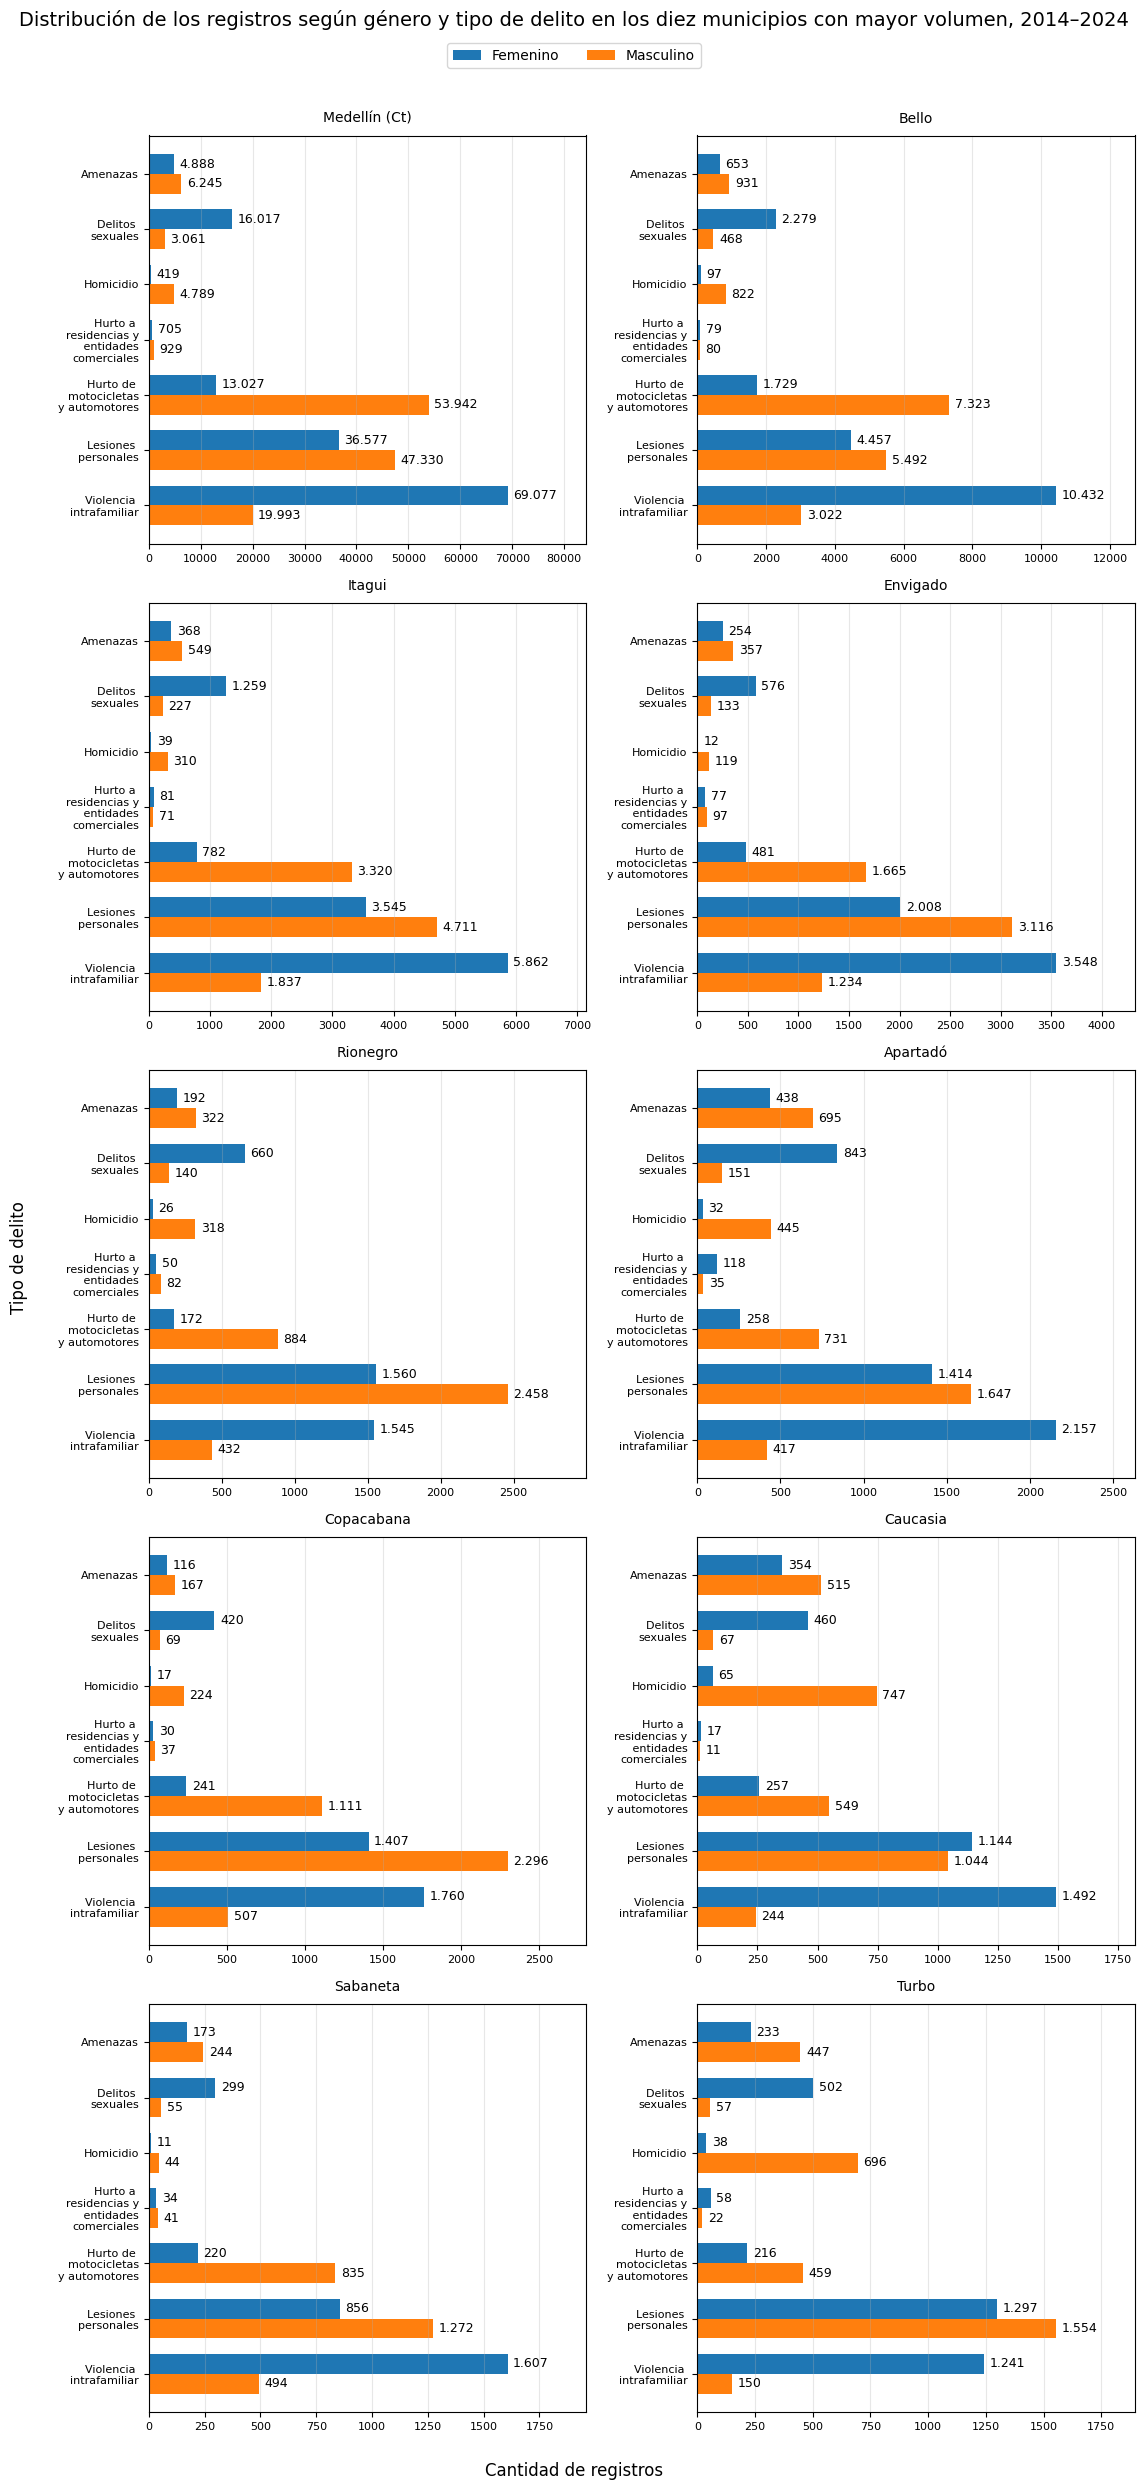

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PREPARACIÓN DE DATOS
# ==========================================================

df_plot = df_municipio_genero.copy()

# Normalizar género
df_plot["genero_limpio"] = (
    df_plot["genero"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Mantener únicamente femenino y masculino
df_plot = df_plot[
    df_plot["genero_limpio"].isin(["FEMENINO", "MASCULINO"])
]

# Orden de los tipos de delito
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

# Etiquetas más cortas para la gráfica
etiquetas_delitos = [
    "Amenazas",
    "Delitos \nsexuales",
    "Homicidio",
    "Hurto a \nresidencias y\n entidades\ncomerciales",
    "Hurto de \nmotocicletas\ny automotores",
    "Lesiones \npersonales",
    "Violencia \nintrafamiliar"
]

# Ordenar municipios según cantidad total de registros
orden_municipios = (
    df_municipio_genero
    .groupby(["municipio", "departamento"])["cantidad_delitos"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# ==========================================================
# FIGURA: 2 COLUMNAS × 5 FILAS (más estrecha y más alta)
# ==========================================================

fig, axes = plt.subplots(
    5, 2,
    figsize=(12, 26)          # ← eje X más corto + figura más alta
)

axes = axes.flatten()

for ax, (municipio, departamento) in zip(axes, orden_municipios):

    # ------------------------------------------------------
    # Filtrar municipio
    # ------------------------------------------------------
    df_municipio = df_plot[
        (df_plot["municipio"] == municipio) &
        (df_plot["departamento"] == departamento)
    ]

    # ------------------------------------------------------
    # Tabla tipo de delito × género
    # ------------------------------------------------------
    tabla = df_municipio.pivot_table(
        index="tipo_delito",
        columns="genero_limpio",
        values="cantidad_delitos",
        aggfunc="sum",
        fill_value=0
    )

    tabla = tabla.reindex(orden_delitos, fill_value=0)

    femenino = tabla.get("FEMENINO", pd.Series(0, index=tabla.index)).to_numpy()
    masculino = tabla.get("MASCULINO", pd.Series(0, index=tabla.index)).to_numpy()

    # ------------------------------------------------------
    # Barras HORIZONTALES agrupadas
    # ------------------------------------------------------
    y = np.arange(len(orden_delitos))
    height = 0.36

    barras_femenino = ax.barh(
        y - height / 2,
        femenino,
        height,
        label="Femenino",
        color="#1f77b4"
    )

    barras_masculino = ax.barh(
        y + height / 2,
        masculino,
        height,
        label="Masculino",
        color="#ff7f0e"
    )

    # ------------------------------------------------------
    # Etiquetas de cantidad al final de las barras
    # ------------------------------------------------------
    for barra in barras_femenino:
        ancho = barra.get_width()
        if ancho > 0:
            ax.annotate(
                f"{int(ancho):,}".replace(",", "."),
                xy=(ancho, barra.get_y() + barra.get_height() / 2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=9
            )

    for barra in barras_masculino:
        ancho = barra.get_width()
        if ancho > 0:
            ax.annotate(
                f"{int(ancho):,}".replace(",", "."),
                xy=(ancho, barra.get_y() + barra.get_height() / 2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=9
            )

    # ------------------------------------------------------
    # Eje Y (tipos de delito)
    # ------------------------------------------------------
    ax.set_yticks(y)
    ax.set_yticklabels(etiquetas_delitos, fontsize=8)
    ax.invert_yaxis()

    # ------------------------------------------------------
    # Eje X (cantidad)
    # ------------------------------------------------------
    max_valor = max(femenino.max(), masculino.max())
    ax.set_xlim(0, max_valor * 1.22)

    ax.ticklabel_format(axis="x", style="plain")
    ax.tick_params(axis="x", labelsize=8)

    # ------------------------------------------------------
    # Título del municipio
    # ------------------------------------------------------
    ax.set_title(
        f"{municipio}",
        fontsize=10,
        pad=9
    )

    # ------------------------------------------------------
    # Cuadrícula
    # ------------------------------------------------------
    ax.grid(axis="x", alpha=0.3)

# ==========================================================
# EJES GENERALES
# ==========================================================

fig.supxlabel("Cantidad de registros", y=0.03, fontsize=12)
fig.supylabel("Tipo de delito", x=0.03, fontsize=12)

fig.suptitle(
    "Distribución de los registros según género y tipo de delito "
    "en los diez municipios con mayor volumen, 2014–2024",
    fontsize=14
)

# ==========================================================
# LEYENDA ÚNICA
# ==========================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.970),
    ncol=2,
    fontsize=10
)

plt.tight_layout(rect=[0.03, 0.03, 0.98, 0.96])

# Guardar la figura
plt.savefig(
    "Resultados/figura_genero_municipios.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

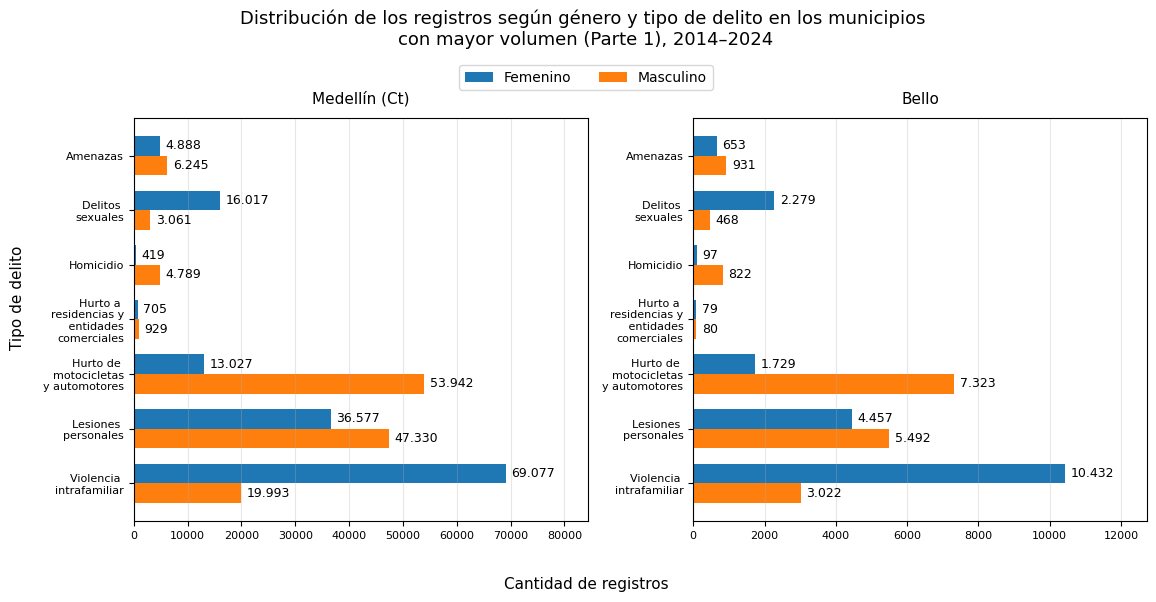

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PREPARACIÓN DE DATOS (igual que antes)
# ==========================================================

df_plot = df_municipio_genero.copy()

df_plot["genero_limpio"] = (
    df_plot["genero"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_plot = df_plot[
    df_plot["genero_limpio"].isin(["FEMENINO", "MASCULINO"])
]

orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

etiquetas_delitos = [
    "Amenazas",
    "Delitos \nsexuales",
    "Homicidio",
    "Hurto a \nresidencias y\n entidades\ncomerciales",
    "Hurto de \nmotocicletas\ny automotores",
    "Lesiones \npersonales",
    "Violencia \nintrafamiliar"
]

orden_municipios = (
    df_municipio_genero
    .groupby(["municipio", "departamento"])["cantidad_delitos"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# ==========================================================
# FIGURA 1: Solo la primera fila (2 municipios)
# ==========================================================

municipios_fig1 = orden_municipios[:2]   # Solo los 2 primeros

fig1, axes1 = plt.subplots(
    1, 2,
    figsize=(12, 6)
)

axes1 = axes1.flatten()

for ax, (municipio, departamento) in zip(axes1, municipios_fig1):

    df_municipio = df_plot[
        (df_plot["municipio"] == municipio) &
        (df_plot["departamento"] == departamento)
    ]

    tabla = df_municipio.pivot_table(
        index="tipo_delito",
        columns="genero_limpio",
        values="cantidad_delitos",
        aggfunc="sum",
        fill_value=0
    ).reindex(orden_delitos, fill_value=0)

    femenino = tabla.get("FEMENINO", pd.Series(0, index=tabla.index)).to_numpy()
    masculino = tabla.get("MASCULINO", pd.Series(0, index=tabla.index)).to_numpy()

    y = np.arange(len(orden_delitos))
    height = 0.36

    barras_f = ax.barh(y - height/2, femenino, height, label="Femenino", color="#1f77b4")
    barras_m = ax.barh(y + height/2, masculino, height, label="Masculino", color="#ff7f0e")

    for barra in list(barras_f) + list(barras_m):
        ancho = barra.get_width()
        if ancho > 0:
            ax.annotate(
                f"{int(ancho):,}".replace(",", "."),
                xy=(ancho, barra.get_y() + barra.get_height()/2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left", va="center",
                fontsize=9
            )

    ax.set_yticks(y)
    ax.set_yticklabels(etiquetas_delitos, fontsize=8)
    ax.invert_yaxis()

    max_valor = max(femenino.max(), masculino.max())
    ax.set_xlim(0, max_valor * 1.22)
    ax.ticklabel_format(axis="x", style="plain")
    ax.tick_params(axis="x", labelsize=8)

    ax.set_title(municipio, fontsize=11, pad=10)
    ax.grid(axis="x", alpha=0.3)

# Ejes y leyenda Figura 1
fig1.supxlabel("Cantidad de registros", fontsize=11)
fig1.supylabel("Tipo de delito", fontsize=11)

fig1.suptitle(
    "Distribución de los registros según género y tipo de delito"
    " en los municipios \ncon mayor volumen (Parte 1), 2014–2024",
    fontsize=13
)

handles, labels = axes1[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.90), ncol=2, fontsize=10)

plt.tight_layout(rect=[0.01, 0.02, 0.98, 0.96])

plt.savefig("Resultados/figura_genero_municipios_parte1.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

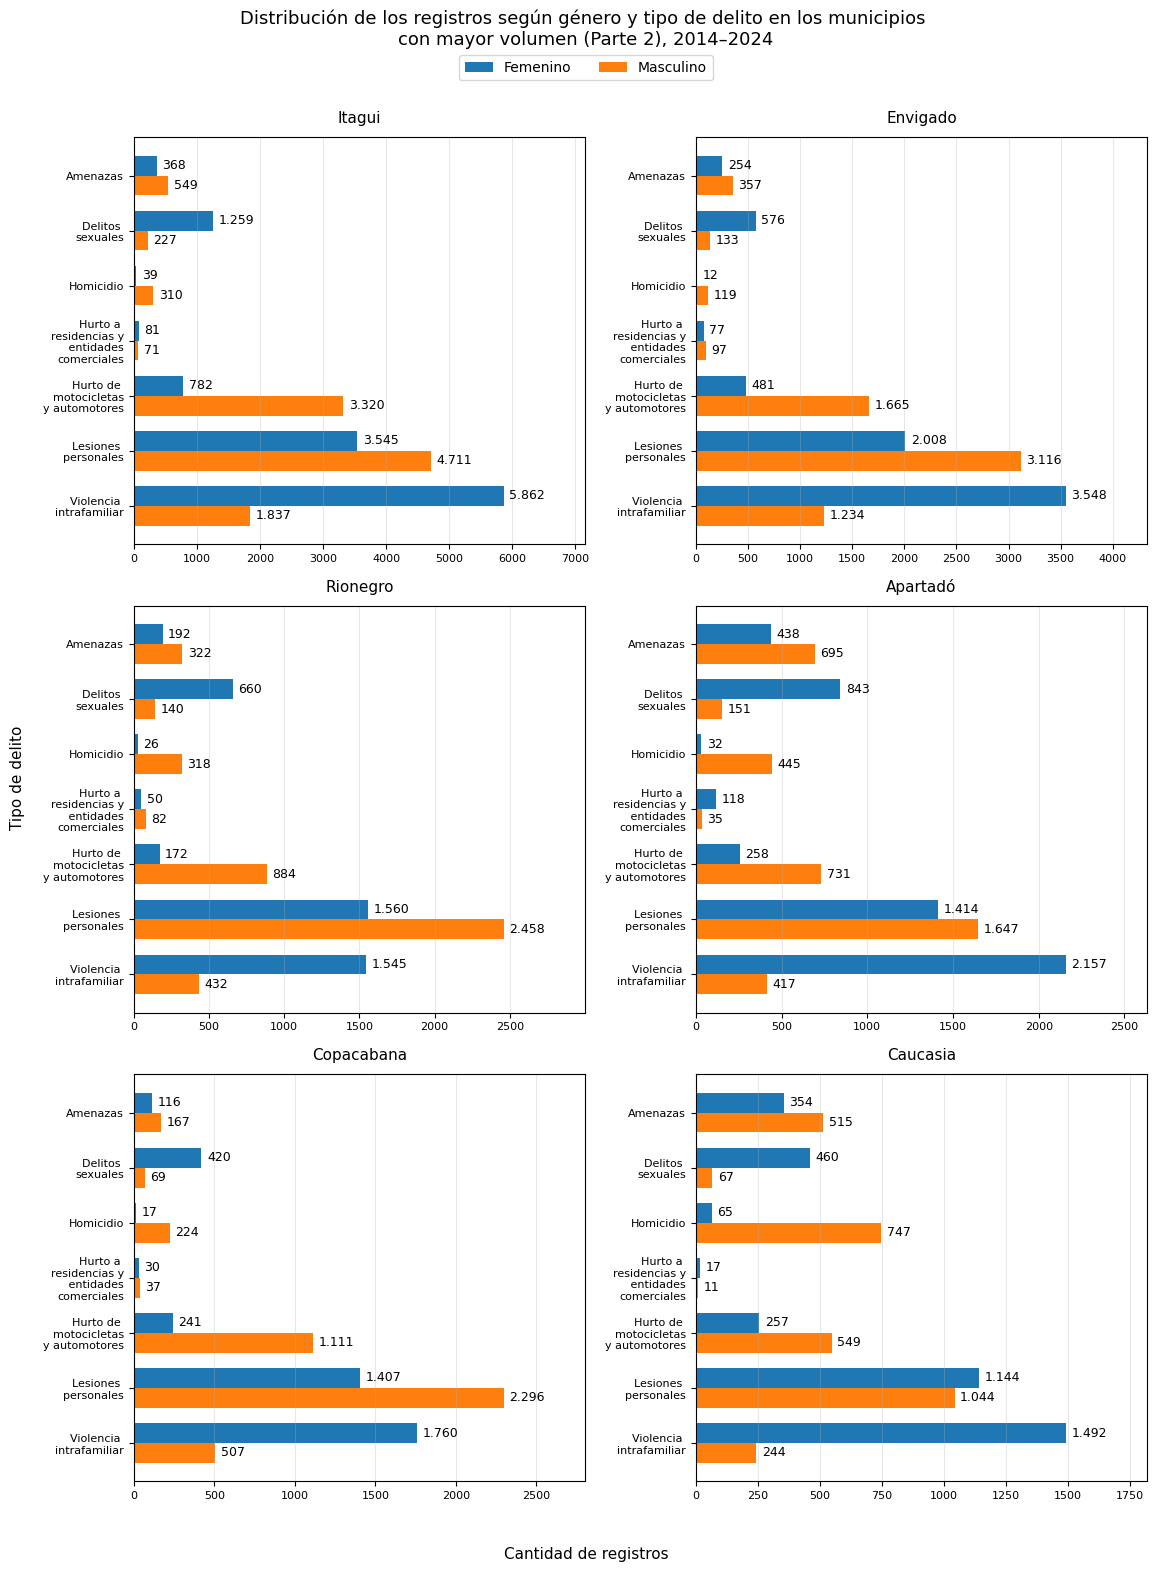

In [102]:
# ==========================================================
# FIGURA 2: Las 4 filas restantes (8 municipios)
# ==========================================================

municipios_fig2 = orden_municipios[2:8]   # Del 3º al 10º

fig2, axes2 = plt.subplots(
    3, 2,
    figsize=(12, 16)
)

axes2 = axes2.flatten()

for ax, (municipio, departamento) in zip(axes2, municipios_fig2):

    df_municipio = df_plot[
        (df_plot["municipio"] == municipio) &
        (df_plot["departamento"] == departamento)
    ]

    tabla = df_municipio.pivot_table(
        index="tipo_delito",
        columns="genero_limpio",
        values="cantidad_delitos",
        aggfunc="sum",
        fill_value=0
    ).reindex(orden_delitos, fill_value=0)

    femenino = tabla.get("FEMENINO", pd.Series(0, index=tabla.index)).to_numpy()
    masculino = tabla.get("MASCULINO", pd.Series(0, index=tabla.index)).to_numpy()

    y = np.arange(len(orden_delitos))
    height = 0.36

    barras_f = ax.barh(y - height/2, femenino, height, label="Femenino", color="#1f77b4")
    barras_m = ax.barh(y + height/2, masculino, height, label="Masculino", color="#ff7f0e")

    for barra in list(barras_f) + list(barras_m):
        ancho = barra.get_width()
        if ancho > 0:
            ax.annotate(
                f"{int(ancho):,}".replace(",", "."),
                xy=(ancho, barra.get_y() + barra.get_height()/2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left", va="center",
                fontsize=9
            )

    ax.set_yticks(y)
    ax.set_yticklabels(etiquetas_delitos, fontsize=8)
    ax.invert_yaxis()

    max_valor = max(femenino.max(), masculino.max())
    ax.set_xlim(0, max_valor * 1.22)
    ax.ticklabel_format(axis="x", style="plain")
    ax.tick_params(axis="x", labelsize=8)

    ax.set_title(municipio, fontsize=11, pad=10)
    ax.grid(axis="x", alpha=0.3)

# Ejes y leyenda Figura 2
fig2.supxlabel("Cantidad de registros", fontsize=11)
fig2.supylabel("Tipo de delito", fontsize=11)

fig2.suptitle(
    "Distribución de los registros según género y tipo de delito"
    " en los municipios \ncon mayor volumen (Parte 2), 2014–2024",
    fontsize=13
)

handles, labels = axes2[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.956), ncol=2, fontsize=10)

plt.tight_layout(rect=[0.01, 0.02, 0.98, 0.96])

plt.savefig("Resultados/figura_genero_municipios_parte2.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

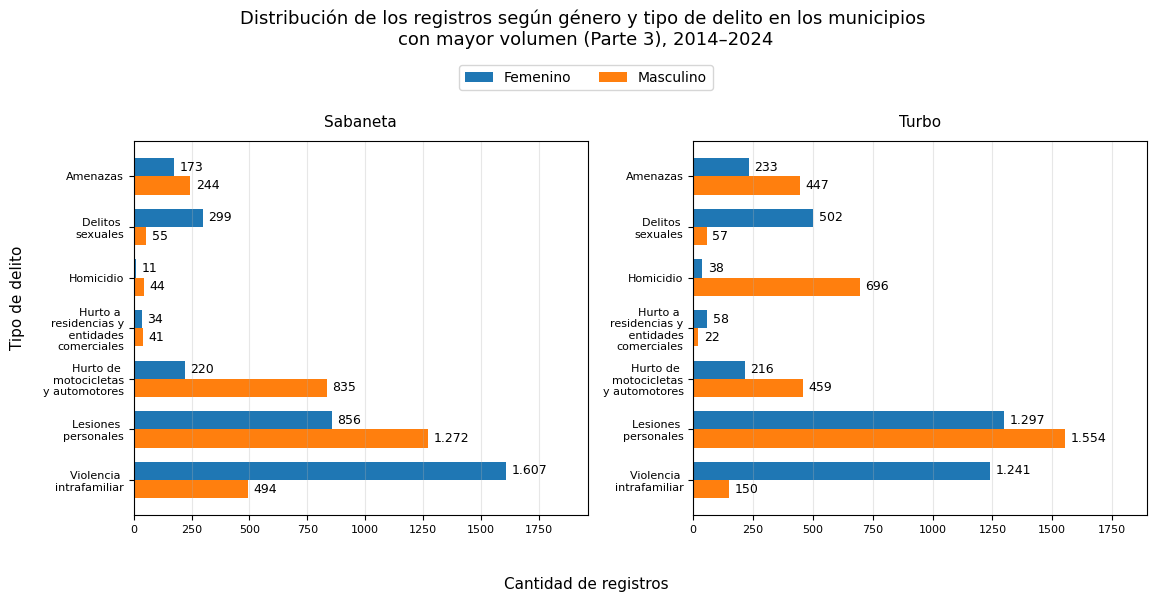

In [103]:
# ==========================================================
# FIGURA 3: La ultima fila
# ==========================================================

municipios_fig3 = orden_municipios[8:]   # Del 3º al 10º

fig3, axes3 = plt.subplots(
    1, 2,
    figsize=(12, 6)
)

axes3 = axes3.flatten()

for ax, (municipio, departamento) in zip(axes3, municipios_fig3):

    df_municipio = df_plot[
        (df_plot["municipio"] == municipio) &
        (df_plot["departamento"] == departamento)
    ]

    tabla = df_municipio.pivot_table(
        index="tipo_delito",
        columns="genero_limpio",
        values="cantidad_delitos",
        aggfunc="sum",
        fill_value=0
    ).reindex(orden_delitos, fill_value=0)

    femenino = tabla.get("FEMENINO", pd.Series(0, index=tabla.index)).to_numpy()
    masculino = tabla.get("MASCULINO", pd.Series(0, index=tabla.index)).to_numpy()

    y = np.arange(len(orden_delitos))
    height = 0.36

    barras_f = ax.barh(y - height/2, femenino, height, label="Femenino", color="#1f77b4")
    barras_m = ax.barh(y + height/2, masculino, height, label="Masculino", color="#ff7f0e")

    for barra in list(barras_f) + list(barras_m):
        ancho = barra.get_width()
        if ancho > 0:
            ax.annotate(
                f"{int(ancho):,}".replace(",", "."),
                xy=(ancho, barra.get_y() + barra.get_height()/2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left", va="center",
                fontsize=9
            )

    ax.set_yticks(y)
    ax.set_yticklabels(etiquetas_delitos, fontsize=8)
    ax.invert_yaxis()

    max_valor = max(femenino.max(), masculino.max())
    ax.set_xlim(0, max_valor * 1.22)
    ax.ticklabel_format(axis="x", style="plain")
    ax.tick_params(axis="x", labelsize=8)

    ax.set_title(municipio, fontsize=11, pad=10)
    ax.grid(axis="x", alpha=0.3)

# Ejes y leyenda Figura 2
fig3.supxlabel("Cantidad de registros", fontsize=11)
fig3.supylabel("Tipo de delito", fontsize=11)

fig3.suptitle(
    "Distribución de los registros según género y tipo de delito"
    " en los municipios \ncon mayor volumen (Parte 3), 2014–2024",
    fontsize=13
)

handles, labels = axes3[0].get_legend_handles_labels()
fig3.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.90), ncol=2, fontsize=10)

plt.tight_layout(rect=[0.01, 0.03, 0.98, 0.92])

plt.savefig("Resultados/figura_genero_municipios_parte3.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

#### **3. Caracterizacion de delitos por medio o arma empleado**

##### **3.1. Caracterizacion general**

In [4]:
query = """
SELECT
    dd.tipo_delito,
    da.nombre_arma,
    SUM(f.cantidad_delitos) AS cantidad_registros
FROM fact_delitos f
JOIN dim_delito dd
    ON f.id_delito = dd.id_delito
JOIN dim_arma da
    ON f.id_arma = da.id_arma
GROUP BY
    dd.tipo_delito,
    da.nombre_arma
ORDER BY
    dd.tipo_delito,
    cantidad_registros DESC;
"""

df_armas = pd.read_sql(query, engine)
df_armas.head()

,tipo_delito,nombre_arma,cantidad_registros
0,Amenazas,SIN EMPLEO DE ARMAS,24335
1,Amenazas,No reportado,4112
2,Amenazas,ARMA DE FUEGO,1652
3,Amenazas,CONTUNDENTES,999
4,Amenazas,ARMA BLANCA / CORTOPUNZANTE,889


Query con filtro de porcentaje y clasificacion en otros

In [ ]:
query = """
WITH datos AS (
    SELECT
        dd.tipo_delito,
        TRIM(da.nombre_arma) AS nombre_arma,
        SUM(f.cantidad_delitos) AS cantidad_registros
    FROM fact_delitos f
    JOIN dim_delito dd
        ON f.id_delito = dd.id_delito
    JOIN dim_arma da
        ON f.id_arma = da.id_arma
    GROUP BY
        dd.tipo_delito, TRIM(da.nombre_arma)
),

totales AS (
    SELECT
        tipo_delito,
        SUM(cantidad_registros) AS total_delito
    FROM datos
    GROUP BY tipo_delito
),

clasificacion AS (
    SELECT
        d.tipo_delito,
        d.nombre_arma,
        d.cantidad_registros,
        ROUND(
            100.0 * d.cantidad_registros / t.total_delito,
            3
        ) AS porcentaje,
        CASE
            WHEN LOWER(TRIM(d.nombre_arma)) = 'no reportado'
                THEN 'No reportado'

            WHEN (
                100.0 * d.cantidad_registros / t.total_delito
            ) >= 5
                THEN d.nombre_arma

            ELSE 'Otros'
        END AS categoria_grafico

    FROM datos d
    JOIN totales t
        ON d.tipo_delito = t.tipo_delito
)

SELECT
    tipo_delito,
    categoria_grafico,
    SUM(cantidad_registros) AS cantidad_registros,
    ROUND(SUM(porcentaje), 3) AS porcentaje
FROM clasificacion
GROUP BY tipo_delito, categoria_grafico
ORDER BY tipo_delito,porcentaje DESC;
"""

df_armas_categorizada = pd.read_sql(query, engine)
df_armas_categorizada.head()

,tipo_delito,categoria_grafico,cantidad_registros,porcentaje
0,Amenazas,SIN EMPLEO DE ARMAS,24335.0,76.002
1,Amenazas,No reportado,4112.0,12.842
2,Amenazas,Otros,1920.0,5.996
3,Amenazas,ARMA DE FUEGO,1652.0,5.159
4,Delitos sexuales,SIN EMPLEO DE ARMAS,25372.0,61.301


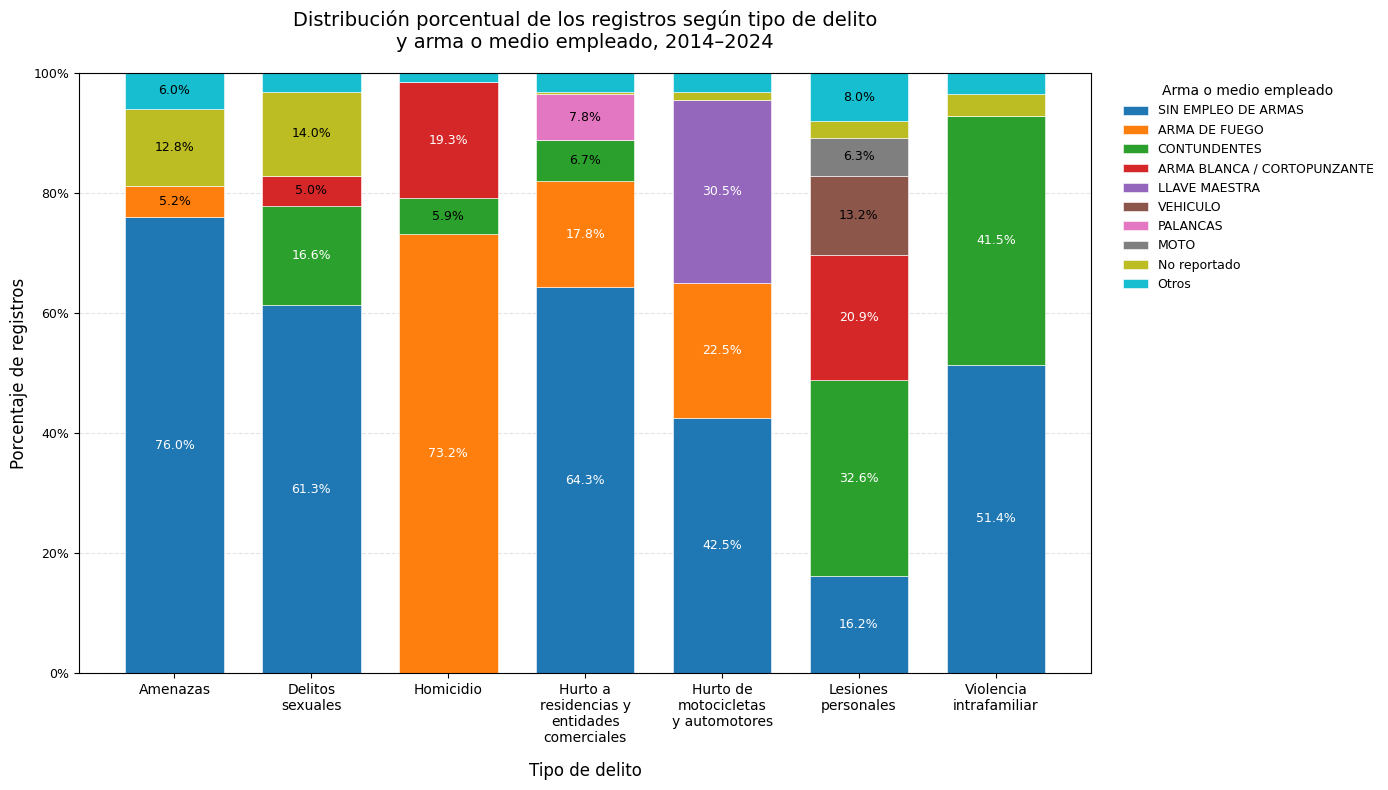

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import PercentFormatter
import numpy as np

# ==========================================================
# 1. DATOS
# ==========================================================
df = df_armas_categorizada.copy()

# ==========================================================
# 2. LIMPIEZA DE TEXTO
# ==========================================================
df["tipo_delito"] = (
    df["tipo_delito"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["categoria_grafico"] = (
    df["categoria_grafico"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# ==========================================================
# 3. ORDEN DE LOS DELITOS
# ==========================================================
orden_delitos = [
    "Amenazas",
    "Delitos sexuales",
    "Homicidio",
    "Hurto a residencias y entidades comerciales",
    "Hurto de motocicletas y automotores",
    "Lesiones personales",
    "Violencia intrafamiliar"
]

df["tipo_delito"] = pd.Categorical(
    df["tipo_delito"],
    categories=orden_delitos,
    ordered=True
)

# ==========================================================
# 4. TABLA PARA EL GRÁFICO
# ==========================================================
tabla = df.pivot(
    index="tipo_delito",
    columns="categoria_grafico",
    values="porcentaje"
).fillna(0)

# ==========================================================
# 5. ORDENAR CATEGORÍAS POR MAGNITUD GLOBAL (mayor → menor)
# ==========================================================
# Suma total de cada categoría a través de todos los delitos
orden_por_magnitud = tabla.sum().sort_values(ascending=False).index.tolist()

# Mover "No reportado" y "Otros" al final (mejor visualmente)
for cat in ["No reportado", "Otros"]:
    if cat in orden_por_magnitud:
        orden_por_magnitud.remove(cat)
        orden_por_magnitud.append(cat)

tabla = tabla[orden_por_magnitud]

# ==========================================================
# 6. NOMBRES PARA EL EJE X
# ==========================================================
nombres_x = [
    "Amenazas",
    "Delitos\nsexuales",
    "Homicidio",
    "Hurto a\nresidencias y\nentidades\ncomerciales",
    "Hurto de\nmotocicletas\ny automotores",
    "Lesiones\npersonales",
    "Violencia\nintrafamiliar"
]

# ==========================================================
# 7. PALETA DE COLORES MEJORADA
# ==========================================================
# Colores distintos y de buen contraste
colores_base = [
    "#1f77b4",  # azul
    "#ff7f0e",  # naranja
    "#2ca02c",  # verde
    "#d62728",  # rojo
    "#9467bd",  # morado
    "#8c564b",  # café
    "#e377c2",  # rosa
    "#7f7f7f",  # gris
    "#bcbd22",  # oliva
    "#17becf",  # cian
    "#aec7e8",  # azul claro
    "#ffbb78",  # naranja claro
]

# Asignar colores según el número de categorías
n_cats = len(orden_por_magnitud)
colores = colores_base[:n_cats]

# ==========================================================
# 8. GRÁFICO
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 8))

bottom = np.zeros(len(tabla))

for i, categoria in enumerate(orden_por_magnitud):
    valores = tabla[categoria].values
    barras = ax.bar(
        range(len(tabla)),
        valores,
        bottom=bottom,
        width=0.72,
        label=categoria,
        color=colores[i],
        edgecolor="white",
        linewidth=0.4
    )

    # Etiquetas solo en segmentos ≥ 5 %
    for j, (bar, val) in enumerate(zip(barras, valores)):
        if val >= 5:
            altura = bottom[j] + val / 2
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                altura,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if val > 15 else "black",
                fontweight="medium"
            )

    bottom += valores

# ==========================================================
# 9. FORMATO
# ==========================================================
ax.set_title(
    "Distribución porcentual de los registros según tipo de delito\ny arma o medio empleado, 2014–2024",
    fontsize=14,
    pad=18
)

ax.set_xlabel("Tipo de delito", fontsize=12, labelpad=12)
ax.set_ylabel("Porcentaje de registros", fontsize=12)

ax.set_xticks(range(len(tabla)))
ax.set_xticklabels(nombres_x, rotation=0, ha="center", fontsize=10)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.tick_params(axis="y", labelsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

# Leyenda
ax.legend(
    title="Arma o medio empleado",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

##### **3.2. Tipo de delito x Top 10 municipios x Arma o medio**

In [20]:
query = """
WITH top_municipios AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        u.departamento,
        SUM(f.cantidad_delitos) AS total_municipio
    FROM fact_delitos AS f
    INNER JOIN dim_ubicacion AS u
        ON f.id_ubicacion = u.id_ubicacion
    GROUP BY
        u.id_ubicacion,
        u.municipio,
        u.departamento
    ORDER BY total_municipio DESC
    LIMIT 10
),

datos AS (
    SELECT
        tm.municipio,
        tm.departamento,
        dd.tipo_delito,
        TRIM(da.nombre_arma) AS nombre_arma,
        SUM(f.cantidad_delitos) AS cantidad_registros
    FROM fact_delitos AS f

    INNER JOIN top_municipios AS tm
        ON f.id_ubicacion = tm.id_ubicacion

    INNER JOIN dim_delito AS dd
        ON f.id_delito = dd.id_delito

    INNER JOIN dim_arma AS da
        ON f.id_arma = da.id_arma

    GROUP BY
        tm.municipio,
        tm.departamento,
        dd.tipo_delito,
        TRIM(da.nombre_arma)
),

totales AS (
    SELECT
        municipio,
        departamento,
        tipo_delito,
        SUM(cantidad_registros) AS total_delito
    FROM datos
    GROUP BY
        municipio,
        departamento,
        tipo_delito
),

clasificacion AS (
    SELECT
        d.municipio,
        d.departamento,
        d.tipo_delito,
        d.nombre_arma,
        d.cantidad_registros,

        ROUND(
            100.0 * d.cantidad_registros / t.total_delito,
            3
        ) AS porcentaje,

        CASE
            WHEN LOWER(TRIM(d.nombre_arma)) = 'no reportado'
                THEN 'No reportado'

            WHEN (
                100.0 * d.cantidad_registros / t.total_delito
            ) >= 5
                THEN d.nombre_arma

            ELSE 'Otros'
        END AS categoria_grafico

    FROM datos AS d

    INNER JOIN totales AS t
        ON d.municipio = t.municipio
        AND d.departamento = t.departamento
        AND d.tipo_delito = t.tipo_delito
),

resultado AS (
    SELECT
        municipio,
        departamento,
        tipo_delito,
        categoria_grafico,
        SUM(cantidad_registros) AS cantidad_registros,
        ROUND(SUM(porcentaje), 3) AS porcentaje
    FROM clasificacion
    GROUP BY
        municipio,
        departamento,
        tipo_delito,
        categoria_grafico
)

SELECT
    municipio,
    departamento,
    tipo_delito,
    categoria_grafico,
    cantidad_registros,
    porcentaje
FROM resultado
ORDER BY
    tipo_delito,
    municipio,
    porcentaje DESC;

"""
df_armas_municipios = pd.read_sql(query, engine)
df_armas_municipios.head()

,municipio,departamento,tipo_delito,categoria_grafico,cantidad_registros,porcentaje
0,Apartadó,Antioquia,Amenazas,SIN EMPLEO DE ARMAS,733.0,64.017
1,Apartadó,Antioquia,Amenazas,No reportado,308.0,26.900
2,Apartadó,Antioquia,Amenazas,Otros,104.0,9.083
3,Bello,Antioquia,Amenazas,SIN EMPLEO DE ARMAS,1251.0,78.630
4,Bello,Antioquia,Amenazas,No reportado,182.0,11.439
